In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
from echofit.echofit import EchoFit

/Users/david/Library/Caches/pypoetry/virtualenvs/echofit-W-NSutmR-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create fake data

In [3]:
# synthetic data
t = np.sort(np.random.uniform(0, 100, 50))

true_signal = np.sin(t / 10.0)

y1 = 2.0 * true_signal + 0.1 * np.random.randn(len(t))
y2 = 1.5 * np.sin((t - 5) / 10.0) + 0.1 * np.random.randn(len(t))

err = 0.1 * np.ones_like(t)

# Create an echofit instance

In [4]:
fit = EchoFit(M_BH=1e8)


# Data Ingestion

In [5]:
fit.add_lightcurve(t, y1, err, wavelength=2000.0)
fit.add_lightcurve(t, y2, err, wavelength=5000.0)

# Plot raw light curves

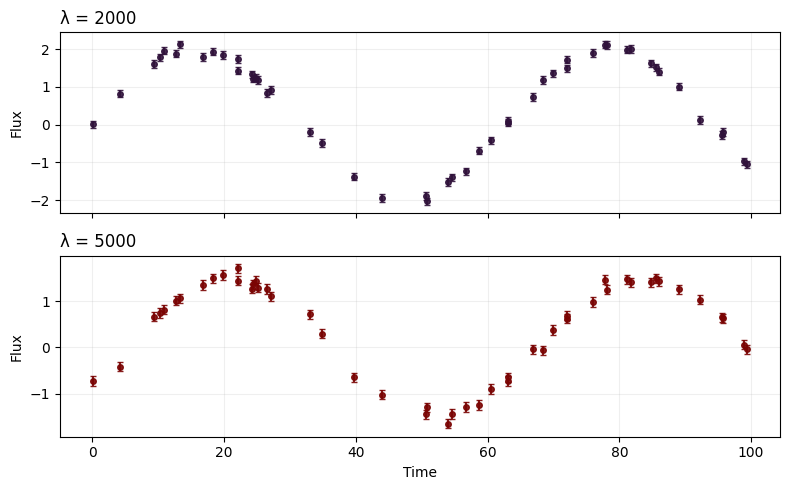

In [6]:
fit.plot_raw_lightcurve_data()

# Run

In [7]:
fit.fit(num_warmup=20, num_samples=20)

sample: 100%|██████████| 40/40 [00:05<00:00,  6.67it/s, 127 steps of size 6.36e-02. acc. prob=0.83] 


# Convergence Diagnostics

In [8]:
samples = fit.mcmc.get_samples()

for k in samples:
    print(k, np.std(samples[k]))

C_0 0.49499553
C_1 0.4955502
S_0 0.8202007
S_1 0.71795505
inclination 0.32205066
log_mdot 0.921256
log_sigma 0.13105783
log_tau_drw 0.29755676


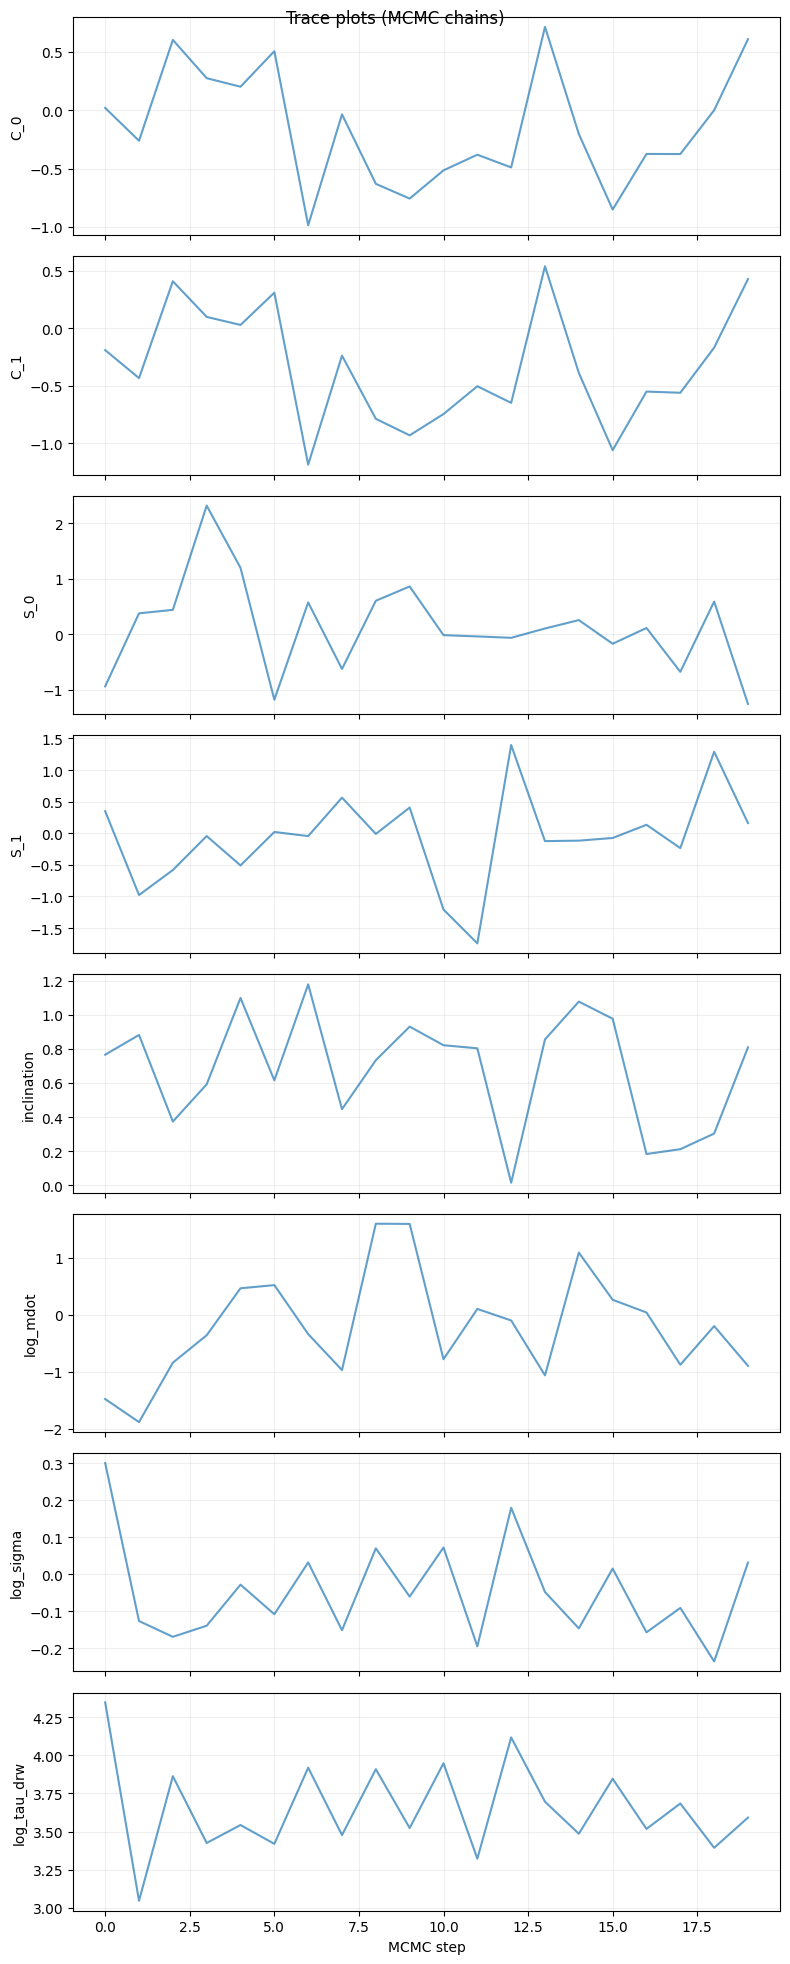

In [9]:
#fit.plot_trace()
#fit.summary()
fit.plot_mcmc_diagnostics()


# Posterior Dstributions

In [10]:
#fit.plot_posterior()

# Light curve fits

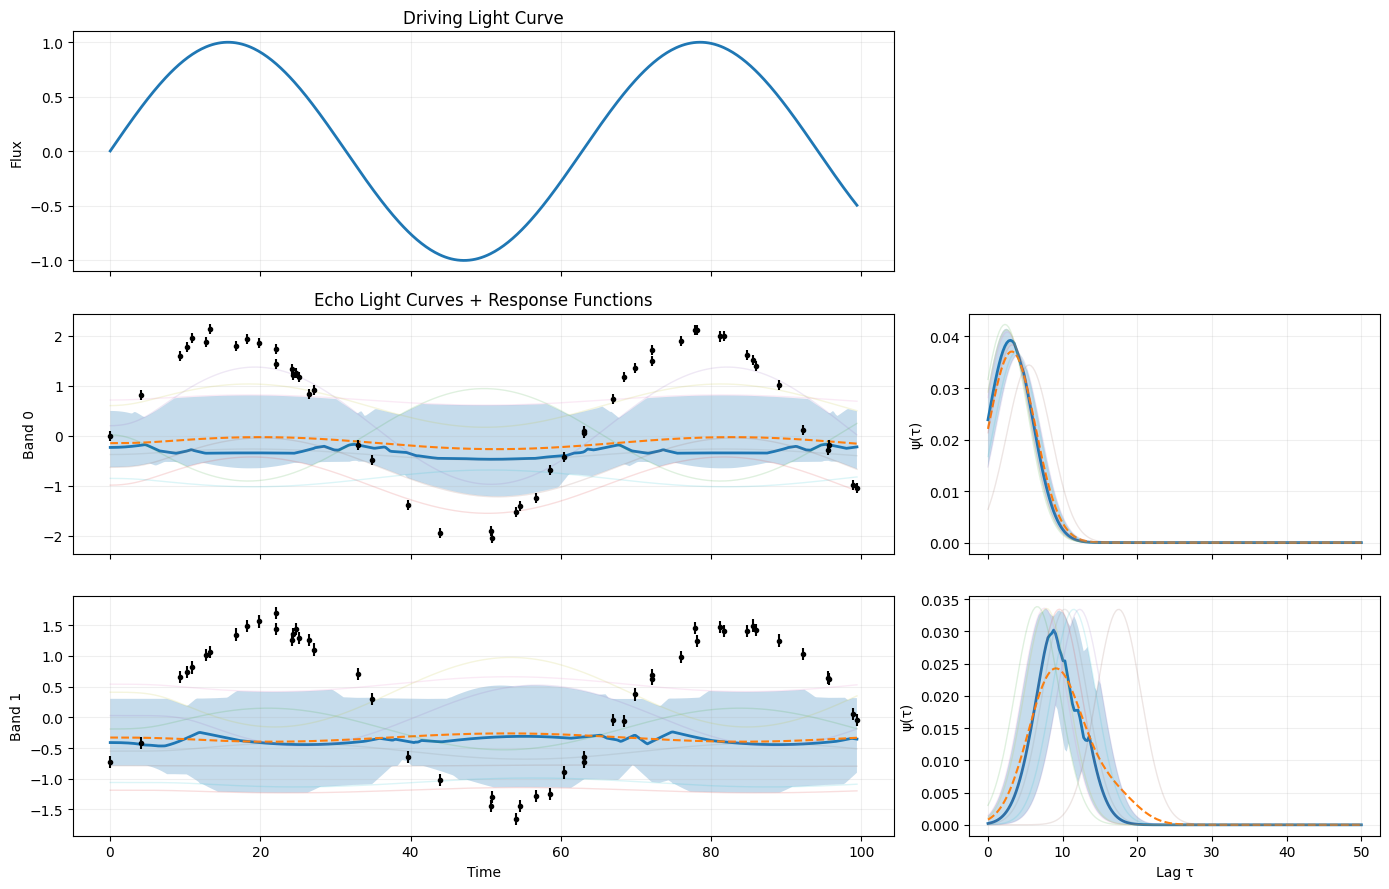

In [13]:
fit.plot_lightcurve_fits()

# Appendix

## Test response function

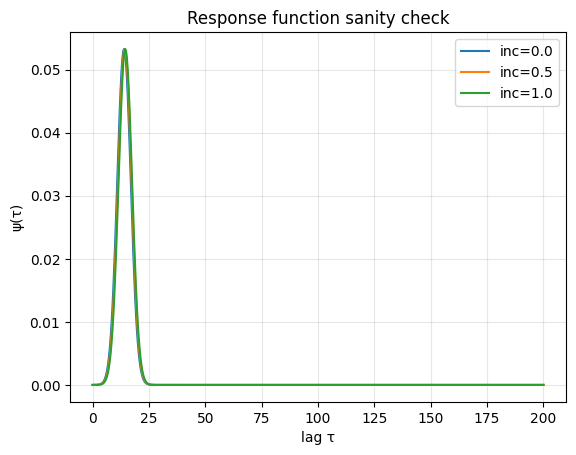

mu = 13.956125
sigma = 4.1868377
skew = 0.7615941559557649
tau range = 0.0 200.0


In [12]:
import numpy as np
import matplotlib.pyplot as plt

from echofit.forward_model import build_response_function, lag_scaling

tau_grid = np.linspace(0, 200, 500)

M_BH = 1e8  # fixed mass

log_mdot = 1.0
wavelength = 5000.0

for inc in [0.0, 0.5, 1.0]:

    psi = build_response_function(
        tau_grid,
        log_mdot,
        wavelength,
        inc,
        M_BH,
    )

    plt.plot(tau_grid, psi, label=f"inc={inc}")

plt.xlabel("lag τ")
plt.ylabel("ψ(τ)")
plt.title("Response function sanity check")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

mu = lag_scaling(log_mdot, wavelength, M_BH)

sigma = 0.3 * mu
skew = np.tanh(inc)

print("mu =", mu)
print("sigma =", sigma)
print("skew =", skew)
print("tau range =", tau_grid.min(), tau_grid.max())